<a href="https://colab.research.google.com/github/Vishwajitp18/Pawar-Vishwajit-Sanjay/blob/main/Phase_1_EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Import Required Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Step 2: Loading the Dataset

In [9]:
import pandas as pd

# Load dataset
file_path = "/content/fertilizer.csv"

fertility = pd.read_csv(file_path)

print("Dataset loaded successfully!")

# Display first 5 records
print(fertility.head())

# Display last 5 records
print(fertility.tail())

# Display dimensions
print("Dataset Shape:", fertility.shape)

# Display dataset information
fertility.info()

# Display column names
print("Column Names:")
print(fertility.columns.tolist())

Dataset loaded successfully!
   rownames morekids gender1 gender2  age afam hispanic other  work
0         1       no  female  female   35   no       no    no    40
1         2       no  female    male   33   no       no    no    52
2         3       no  female  female   28   no       no    no    12
3         4       no    male    male   28   no       no    no     0
4         5       no  female    male   31   no       no    no     0
       rownames morekids gender1 gender2  age afam hispanic other  work
29995     29996      yes    male  female   34   no       no    no     0
29996     29997       no    male    male   30   no       no    no     4
29997     29998      yes    male  female   34   no       no    no    42
29998     29999      yes    male    male   31  yes       no    no    52
29999     30000       no  female  female   29   no       no    no     0
Dataset Shape: (30000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 9 columns

Step 3: Basic Statistical Analysis

In [10]:
# Summary Statistics
print("Summary Statistics")
print(fertility.describe(include='all'))

# Mean
print("\nMean:")
print(fertility.mean(numeric_only=True))

# Median
print("\nMedian:")
print(fertility.median(numeric_only=True))

# Mode
print("\nMode:")
print(fertility.mode().iloc[0])

# Standard Deviation
print("\nStandard Deviation:")
print(fertility.std(numeric_only=True))

# Variance
print("\nVariance:")
print(fertility.var(numeric_only=True))

# Minimum Values
print("\nMinimum Values:")
print(fertility.min(numeric_only=True))

# Maximum Values
print("\nMaximum Values:")
print(fertility.max(numeric_only=True))

# Correlation Matrix
print("\nCorrelation Matrix:")
num_data = fertility.select_dtypes(include='number')
print(num_data.corr())

Summary Statistics
            rownames morekids gender1 gender2           age   afam hispanic  \
count   30000.000000    30000   30000   30000  30000.000000  30000    30000   
unique           NaN        2       2       2           NaN      2        2   
top              NaN       no    male    male           NaN     no       no   
freq             NaN    18672   15451   15182           NaN  28402    27768   
mean    15000.500000      NaN     NaN     NaN     30.354267    NaN      NaN   
std      8660.398374      NaN     NaN     NaN      3.383432    NaN      NaN   
min         1.000000      NaN     NaN     NaN     21.000000    NaN      NaN   
25%      7500.750000      NaN     NaN     NaN     28.000000    NaN      NaN   
50%     15000.500000      NaN     NaN     NaN     31.000000    NaN      NaN   
75%     22500.250000      NaN     NaN     NaN     33.000000    NaN      NaN   
max     30000.000000      NaN     NaN     NaN     35.000000    NaN      NaN   

        other          work  
co

Step 4: Handling Missing Data

In [7]:
print("Missing Values")
print(fertility.isnull().sum())

print("\nPercentage of Missing Values")
print((fertility.isnull().sum()/len(fertility))*100)

# Fill missing values in numeric columns
fertility = fertility.fillna(fertility.mean(numeric_only=True))

print("\nMissing Values After Filling")
print(fertility.isnull().sum())

Missing Values
rownames    0
morekids    0
gender1     0
gender2     0
age         0
afam        0
hispanic    0
other       0
work        0
dtype: int64

Percentage of Missing Values
rownames    0.0
morekids    0.0
gender1     0.0
gender2     0.0
age         0.0
afam        0.0
hispanic    0.0
other       0.0
work        0.0
dtype: float64

Missing Values After Filling
rownames    0
morekids    0
gender1     0
gender2     0
age         0
afam        0
hispanic    0
other       0
work        0
dtype: int64


Step 5: Data Cleaning

In [12]:
# Remove duplicate rows
fertility = fertility.drop_duplicates()

print("Duplicate Rows:", fertility.duplicated().sum())

print("\nData Types")
print(fertility.dtypes)

Duplicate Rows: 0

Data Types
rownames     int64
morekids    object
gender1     object
gender2     object
age          int64
afam        object
hispanic    object
other       object
work         int64
dtype: object


Step 6: Data Transformation

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

fertility_norm = fertility.copy()

numeric_cols = fertility_norm.select_dtypes(include='number').columns

fertility_norm[numeric_cols] = scaler.fit_transform(
    fertility_norm[numeric_cols]
)

print(fertility_norm.head())

   rownames morekids gender1 gender2       age afam hispanic other      work
0  0.000000       no  female  female  1.000000   no       no    no  0.769231
1  0.000033       no  female    male  0.857143   no       no    no  1.000000
2  0.000067       no  female  female  0.500000   no       no    no  0.230769
3  0.000100       no    male    male  0.500000   no       no    no  0.000000
4  0.000133       no  female    male  0.714286   no       no    no  0.000000


Step 7: Univariate Analysis

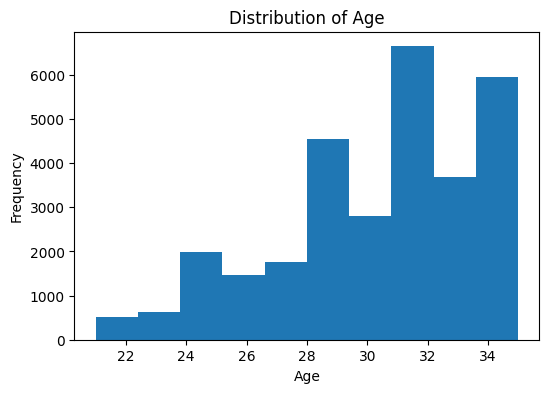

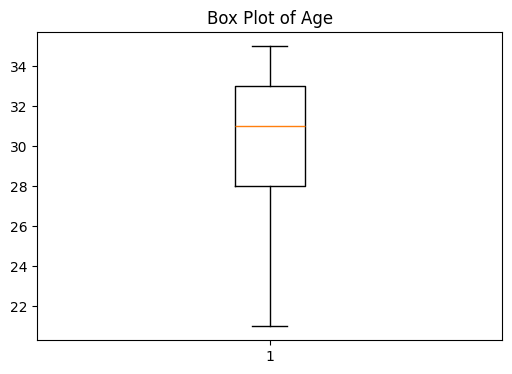

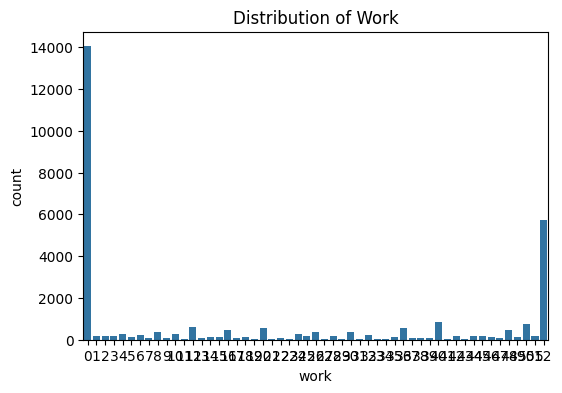

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram
plt.figure(figsize=(6,4))
plt.hist(fertility["age"], bins=10)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Box Plot
plt.figure(figsize=(6,4))
plt.boxplot(fertility["age"])
plt.title("Box Plot of Age")
plt.show()

# Count Plot
plt.figure(figsize=(6,4))
sns.countplot(x="work", data=fertility)
plt.title("Distribution of Work")
plt.show()

Step 8: Bivariate Analysis

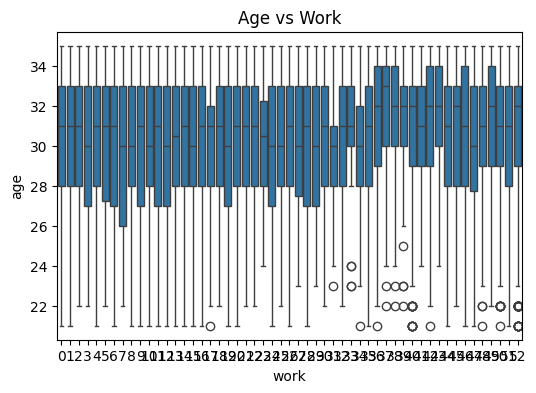

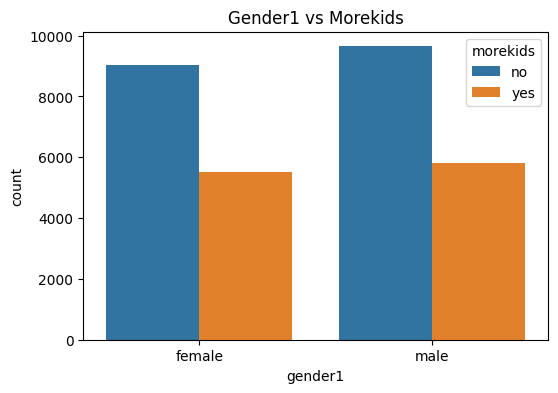

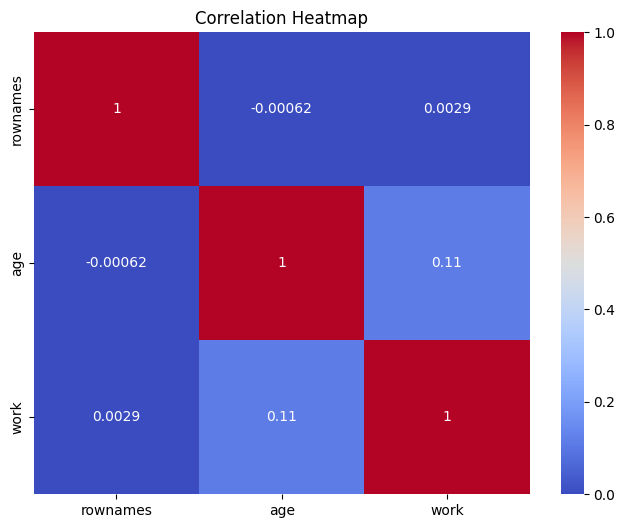

In [15]:
# Age vs Work
plt.figure(figsize=(6,4))
sns.boxplot(x="work", y="age", data=fertility)
plt.title("Age vs Work")
plt.show()

# Gender1 vs Morekids
plt.figure(figsize=(6,4))
sns.countplot(x="gender1", hue="morekids", data=fertility)
plt.title("Gender1 vs Morekids")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(num_data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Step 9: Multivariate Analysis

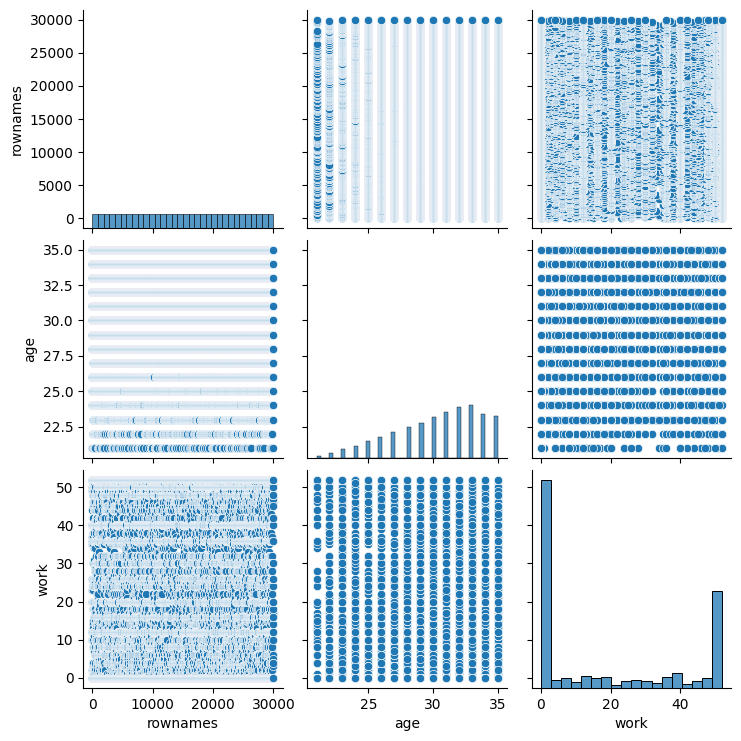

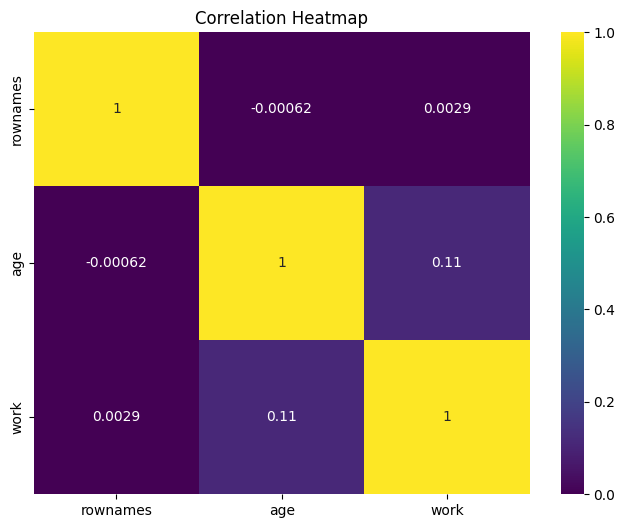

/usr/local/lib/python3.12/dist-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


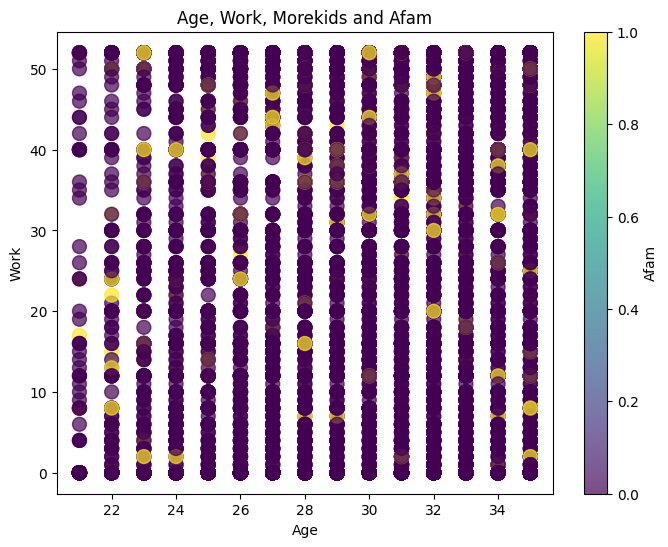

In [16]:
# Pair Plot
sns.pairplot(num_data)
plt.show()

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(num_data.corr(), annot=True, cmap="viridis")
plt.title("Correlation Heatmap")
plt.show()

# Bubble Plot

fertility["morekids_code"] = fertility["morekids"].astype("category").cat.codes
fertility["afam_code"] = fertility["afam"].astype("category").cat.codes
fertility["work_code"] = fertility["work"].astype("category").cat.codes

plt.figure(figsize=(8,6))

plt.scatter(
    fertility["age"],
    fertility["work_code"],
    s=(fertility["morekids_code"]+1)*100,
    c=fertility["afam_code"],
    alpha=0.7
)

plt.xlabel("Age")
plt.ylabel("Work")
plt.title("Age, Work, Morekids and Afam")

plt.colorbar(label="Afam")

plt.show()

Step 10: Conclusion

In [17]:
print("EDA Completed Successfully")

EDA Completed Successfully
